# This is a demonstration of Synthesizer
## 1) Define a Grid object

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from synthesizer import Grid
# Return to the unmodified grid
grid = Grid("test_grid")

log10age = 6.0  # log10(age/yr)
Z = 0.01  # metallicity
grid_point = grid.get_grid_point(log10ages=log10age, metallicities=Z)

## 2) Obtain SED from the Grid object

Text(0, 0.5, '$\\rm log_{10}(L_{\\nu}/erg\\ s^{-1}\\ Hz^{-1} M_{\\odot}^{-1})$')

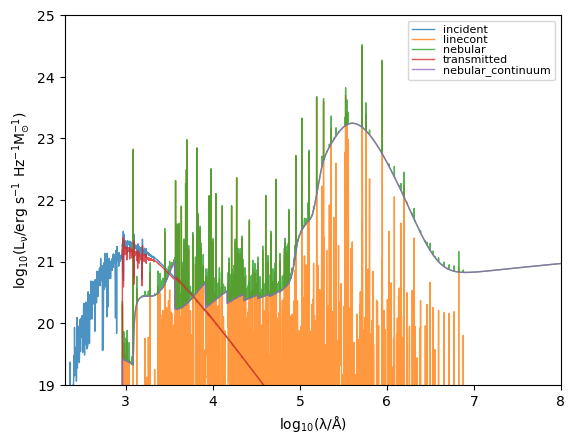

In [85]:
for spectra_type in grid.available_spectra:
    # Get `Sed` object
    sed = grid.get_sed_at_grid_point(grid_point, spectra_type=spectra_type)

    # Mask zero valued elements
    mask = sed.lnu > 0
    plt.plot(
        np.log10(sed.lam[mask]),
        np.log10(sed.lnu[mask]),
        lw=1,
        alpha=0.8,
        label=spectra_type,
    )

plt.legend(fontsize=8, labelspacing=0.0)
plt.xlim(2.3, 8)
plt.ylim(19, 25)
plt.xlabel(r"$\rm log_{10}(\lambda/\AA)$")
plt.ylabel(r"$\rm log_{10}(L_{\nu}/erg\ s^{-1}\ Hz^{-1} M_{\odot}^{-1})$")

## Galaxies & Components
### 3.1) Create Particle Stars

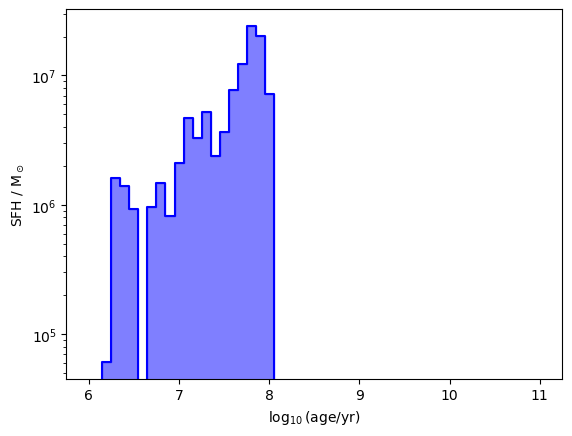

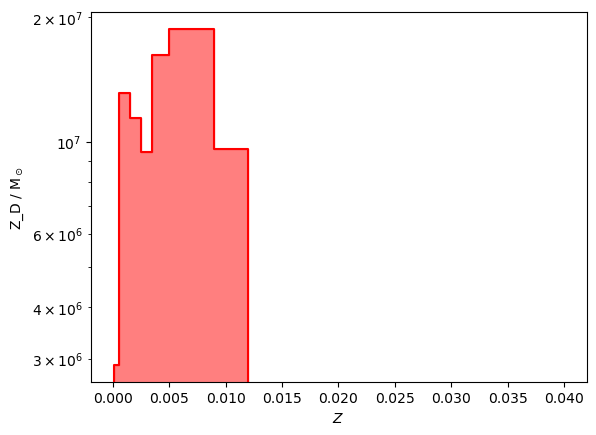

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$Z$', ylabel='Z_D / M$_\\odot$'>)

In [40]:
from synthesizer.particle import Stars, Gas, BlackHoles, Galaxy
from unyt import Myr, Msun, Mpc, yr

N = 100
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

stars.plot_sfh(grid.log10ages)
stars.plot_metal_dist(grid.metallicities)

### 3.2) Create Gas

In [36]:
gas = Gas(
    masses=np.ones(1000) * 10**6 * Msun,
    metallicities=np.random.rand(1000) * 0.02,
    dust_to_metal_ratio=0.25,
    coordinates=np.random.rand(1000, 3) * 1 * Mpc,
    centre=np.mean(np.random.rand(1000, 3) * 1, axis=0) * Mpc,
    hii_mass=np.random.rand(1000) * 1e4 * Msun,
    hii_metallicity=np.random.rand(1000) * 0.02,
)
print(gas)

+---------------------------------------------------------------------------------------+
|                                          GAS                                          |
+--------------------------------+------------------------------------------------------+
| Attribute                      | Value                                                |
+--------------------------------+------------------------------------------------------+
| nparticles                     | 1000                                                 |
+--------------------------------+------------------------------------------------------+
| metallicity_floor              | 1.00e-05                                             |
+--------------------------------+------------------------------------------------------+
| name                           | 'Gas'                                                |
+--------------------------------+------------------------------------------------------+
| componen

### 3.3) Create Black Holes

In [37]:
# Make fake properties
n = 4
masses = 10 ** np.random.uniform(low=7, high=9, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)

# And get the black holes object
bh = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
)

## 3.x) parametric Star Formation History

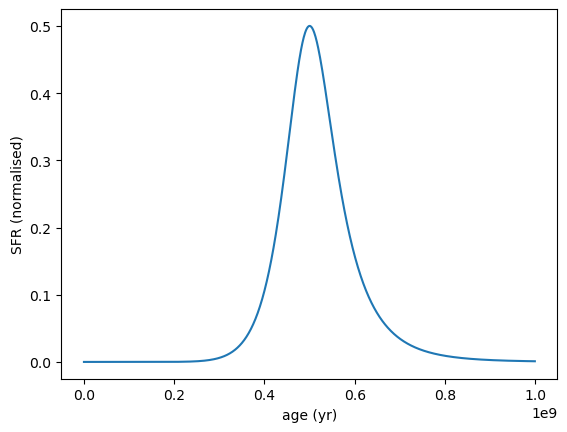

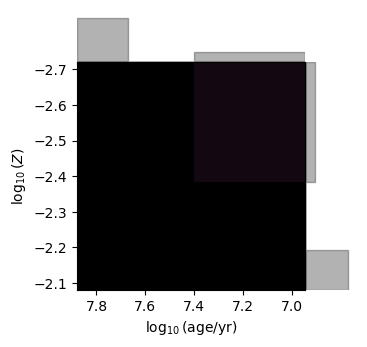

(<Figure size 350x350 with 3 Axes>,
 <Axes: xlabel='$\\log_{10}(\\mathrm{age}/\\mathrm{yr})$', ylabel='$\\log_{10}(Z)$'>)

In [76]:
from unyt import yr
from synthesizer.parametric import SFH

sfh = SFH.DoublePowerLaw(
    peak_age=5e8 * yr, alpha=10, beta=-10, max_age=1e9 * yr
)

sfh.plot_sfh(t_range=(0, 1e9))

N = 100
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

param_stars = Stars(ages=ages, metallicities=metallicities,
                    sf_hist=sfh, initial_masses=initial_masses)
param_stars.get_sfzh(log10ages=np.log10(ages), metallicities=metallicities)
param_stars.plot_sfzh()

## 4) Emissions


In [ ]:
from unyt import Angstrom, Hz, erg, eV, s, um
from synthesizer import Sed

# # Define some wavelengths and luminosities densities
# lams = np.logspace(3, 5, 100) * Angstrom
# lnus = np.logspace(26, 30, 100) * erg / (s * Hz)

# # Create a Sed object
# sed = Sed(lams, lnus)

In [89]:
print(sed.wavelength)
print(sed.luminosity_nu)

[1.29662e-04 1.33601e-04 1.37660e-04 ... 2.97304e+11 2.98297e+11
 2.99293e+11] Å
[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.16911230e+18
 2.15177879e+18 2.13430303e+18] erg/(Hz*s)


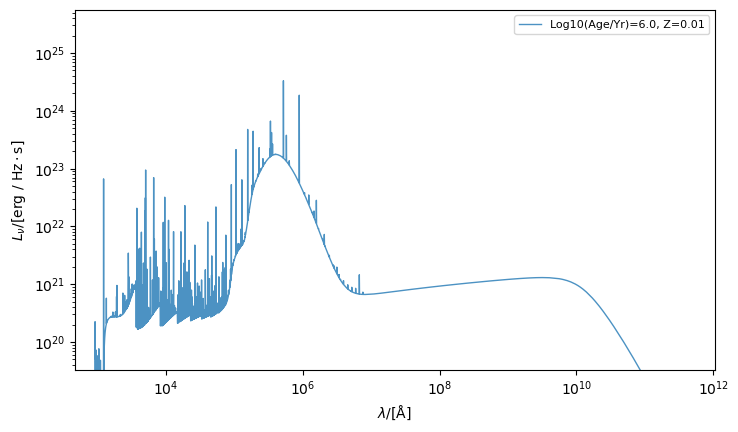

In [104]:
fig, ax = sed.plot_spectra(figsize=(8,6), label=f"log10(age/yr)={log10age}, Z={Z}")

unyt_quantity(2.40978179e+36, 'erg/s')

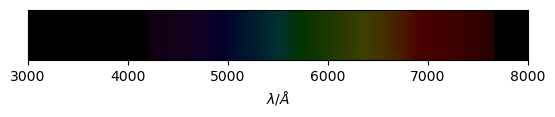

In [98]:
fig, ax = sed.plot_spectra_as_rainbow()
sed.bolometric_luminosity

### Applying attenuation

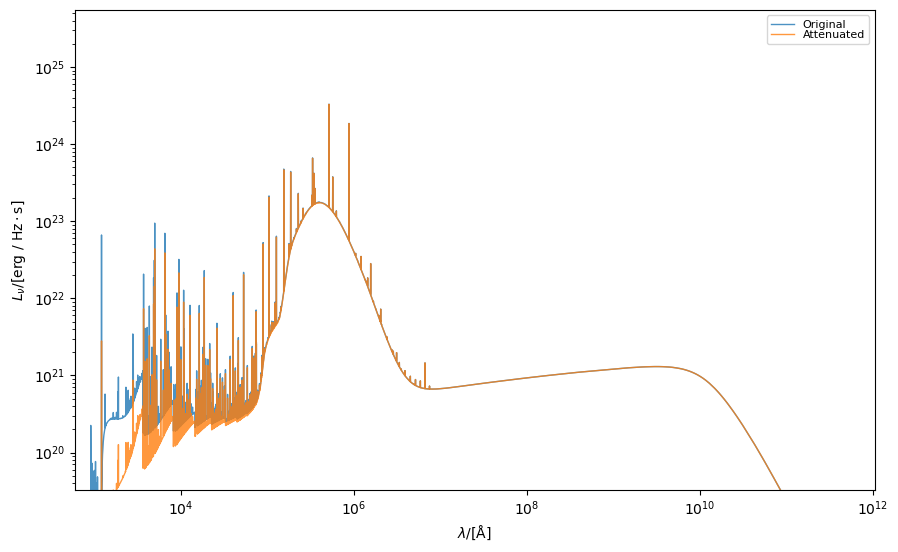

In [107]:
from synthesizer.emission_models.attenuation import PowerLaw

sed_att = sed.apply_attenuation(tau_v=0.7, dust_curve=PowerLaw(-1.0))

# Integrate the multidimensional spectra
int_sed = sed.sum()
int_sed_att = sed_att.sum()

fig, ax = int_sed.plot_spectra(label="Original", figsize=(10,8))
fig, ax = int_sed_att.plot_spectra(label="Attenuated", fig=fig, ax=ax)

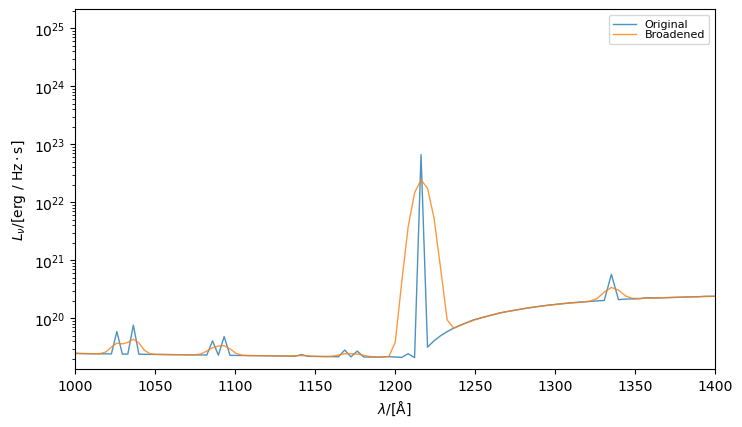

In [106]:
from unyt import km, s

log10age = 6.0  # log10(age/yr)
metallicity = 0.01
spectra_type = "nebular"
grid_point = grid.get_grid_point(log10ages=log10age, metallicities=metallicity)

# Extract SED
sed = grid.get_sed_at_grid_point(grid_point, spectra_type=spectra_type)

# Apply Doppler broadening specifying a velocity
sed_broadened = sed.doppler_broaden(1000.0 * km / s)

# Plot to compare
fig, ax = sed.plot_spectra(label="original", figsize=(8,6))
fig, ax = sed_broadened.plot_spectra(
    label="broadened", fig=fig, ax=ax, xlimits=(1000, 1400)
)
ax.set_xscale("linear")